In [20]:
import os
import glob
import sqlite3
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense
from keras.callbacks import EarlyStopping
from dataclasses import dataclass



from config import *

# ==========================================
# 1. DATA LOADING
# ==========================================
def load_and_merge_data(*db_files: list[str]) -> pd.DataFrame:
	all_data: list[pd.DataFrame] = []


	# Scan for db files
	# db_files: list[str] = glob.glob(os.path.join(folder_path, "*.db"))
	# db_files: list[str] = database_path
	
	if not db_files:
		print("No .db files found! Make sure your files are in the 'datasets' folder.")
		return pd.DataFrame()

	print(f"Found {len(db_files)} database files.")


	for db_file in db_files:

		filename: str = os.path.basename(db_file)

		print(f"Loading '{filename}'...")
		with sqlite3.connect(db_file) as conn:
			lables: pd.DataFrame = pd.read_sql_query("select name from sqlite_master where type='table';", conn)

			print(f"Found {len(lables)} labels in '{filename}'.")

			for label in lables["name"]:
				print(label)


				df: pd.DataFrame = pd.read_sql_query(f"SELECT {", ".join(DATA_CODEC.get_columns())} FROM {label} ORDER BY {ORDER_TABLE_BY}", conn)

				#Labelling the data
				df[LABLE_COLUMN] = label
				all_data.append(df)
				print(f"  -> Loaded {len(df)} samples.")


	if not all_data:
		return pd.DataFrame()

	return pd.concat(all_data, ignore_index=True)



# Array for containing windows
# A window is a timeframe, which is analized to determin the current action  
window_list_type = np.ndarray[np.ndarray[float]]

# Array for containing the corresponding lables for the windows
# Each window is catogarized into a lable
lable_list_type = np.ndarray[str]

# Similar in function to lable_list_type
# A lable is a string, but the model cannot output a string
# Therefore the lables are converted into catagories
# e.g lables: "egg", "bacon", "ham" -> catagories [1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]
catagory_list_type = np.ndarray[np.ndarray[float]]


# Similar in function to catagory_list_type
# e.g catagories [1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0] -> encoded 0, 1, 2
catagory_list_indecies_type = np.ndarray[int]


class DataList:
	def __init__(self, windows_train_list: window_list_type, lables_train_list: lable_list_type, windows_val_list: window_list_type, lables_val_list: lable_list_type, windows_test_list: window_list_type, lables_test_list: lable_list_type):
		
		#Storing training data
		#3D array list[][WINDOW_SIZE][3]
		self.windows_train_raw : window_list_type = windows_train_list
		self.windows_val_raw   : window_list_type = windows_val_list
		self.windows_test_raw  : window_list_type = windows_test_list
		
		#Format: list of label strings
		self.lables_train  : lable_list_type  = lables_train_list
		self.lables_val    : lable_list_type  = lables_val_list
		self.lables_test   : lable_list_type  = lables_test_list

		# Encode Labels
		self.label_encoder = LabelEncoder()
		# Fit on all labels to ensure we know all classes
		self.label_encoder.fit(self.get_all_labels())

		self.classes: np.array = self.label_encoder.classes_
		self.num_classes = len(self.classes)
		print("Label Mapping:", dict(zip(range(self.num_classes), self.classes)))

		# Convert to One-Hot Encoding 
		self.catagories_train : catagory_list_type = to_categorical(self.label_encoder.transform(self.lables_train))
		self.catagories_val   : catagory_list_type = to_categorical(self.label_encoder.transform(self.lables_val))
		self.catagories_test  : catagory_list_type = to_categorical(self.label_encoder.transform(self.lables_test))



		self.catagories_train_indicies : catagory_list_indecies_type = np.argmax(self.catagories_train, axis = 1)
		self.catagories_val_indicies   : catagory_list_indecies_type = np.argmax(self.catagories_val,   axis = 1)
		self.catagories_test_indicies  : catagory_list_indecies_type = np.argmax(self.catagories_test,  axis = 1)


		# Calculating the mean and standard deviation
		# To calculate the mean and deviation, the windows are irrelevant. Therefor the training data is flatend into an array of data points
		windows_train_flat: np.ndarray[np.ndarray[float]] = self.windows_train_raw.reshape(-1, DATA_CODEC.get_dimensions())
		self.mean: np.ndarray[float] = np.mean(windows_train_flat, axis=0)
		self.standard_deviation: np.ndarray[float] = np.std(windows_train_flat, axis=0)

		self.windows_train_normalized : window_list_type = (self.windows_train_raw - self.mean) / self.standard_deviation
		self.windows_val_normalized   : window_list_type = (self.windows_val_raw   - self.mean) / self.standard_deviation
		self.windows_test_normalized  : window_list_type = (self.windows_test_raw  - self.mean) / self.standard_deviation




	def get_all_labels(self):
		return np.concatenate([self.lables_train, self.lables_val, self.lables_test])

	def total_windows(self) -> int:
		return len(self.windows_train_raw) + len(self.windows_val_raw) + len(self.windows_test_raw)




# ==========================================
# 2. PREPROCESSING & SPLITTING
# ==========================================
def create_windows_from_array(data_array, label: str, window_size: int, step_size: int) -> tuple[list[list], list[str]]:
	windows: list[list] = []
	labels: list[str] = []
	# Loop over the array to create windows
	for i in range(0, len(data_array) - window_size + 1, step_size):
		window = data_array[i : i + window_size]
		windows.append(window)
		labels.append(label)
	return windows, labels

def robust_time_split(df: pd.DataFrame, window_size: int, step_size: int, val_ratio: float = 0.15, test_ratio: float = 0.15):
	
	windows_train_list : list[list[list[float]]] = []
	windows_val_list   : list[list[list[float]]] = []
	windows_test_list  : list[list[list[float]]] = []
	lables_train_list  : list[str]               = []
	lables_val_list    : list[str]               = []
	lables_test_list   : list[str]               = []
	

	# Process each lable separately by splitting the merged data into groups by the lables
	for label, group in df.groupby(LABLE_COLUMN):
		
		sensor_data : list[list[float]] = group[DATA_CODEC.get_columns()].values
		total_len   : int = len(sensor_data)

		# Calculate split indices based on time
		# Train ends where Val begins
		train_end_idx: int = int(total_len * (1 - val_ratio - test_ratio))
		# Val ends where Test begins
		val_end_idx: int = int(total_len * (1 - test_ratio))

		# Split raw data by time
		train_segment : list[list[float]] = sensor_data[:train_end_idx]
		val_segment   : list[list[float]] = sensor_data[train_end_idx:val_end_idx]
		test_segment  : list[list[float]] = sensor_data[val_end_idx:]
		
		# Create windows for each segment
		w_train, l_train = create_windows_from_array(train_segment, label, window_size, step_size)
		w_val,   l_val   = create_windows_from_array(val_segment,   label, window_size, step_size)
		w_test,  l_test  = create_windows_from_array(test_segment,  label, window_size, step_size)
		
		windows_train_list.extend(w_train)
		lables_train_list.extend(l_train)
		windows_val_list.extend(w_val)
		lables_val_list.extend(l_val)
		windows_test_list.extend(w_test)
		lables_test_list.extend(l_test)

	return DataList(np.array(windows_train_list), np.array(lables_train_list), 
			np.array(windows_val_list), np.array(lables_val_list),
			np.array(windows_test_list), np.array(lables_test_list))




# Create the output folder if it doesn't exist
if not os.path.exists(OUTPUT_FOLDER):
	os.makedirs(OUTPUT_FOLDER)
	print(f"Created output directory: {OUTPUT_FOLDER}")

# Load the data
print("--- STARTING DATA LOAD ---")
data: pd.DataFrame = load_and_merge_data(DATABASE_PATH)




if data.empty:
	print("No data loaded. Please check your .db files.")
	exit()




#TODO: Comment
# Perform the Time-Based Split
data_list: DataList = robust_time_split(
	data, WINDOW_SIZE, STEP_SIZE, val_ratio=0.15, test_ratio=0.15
)

print(f"\nTotal Windows: {data_list.total_windows()}")
print(f"Train Windows:   {len(data_list.windows_train_raw)}")
print(f"Val Windows:     {len(data_list.windows_val_raw)}")
print(f"Test Windows:    {len(data_list.windows_test_raw)}")








--- STARTING DATA LOAD ---
Found 1 database files.
Loading 'joystick.db'...
Found 4 labels in 'joystick.db'.
circle
  -> Loaded 8000 samples.
updown
  -> Loaded 7999 samples.
leftright
  -> Loaded 8000 samples.
idle
  -> Loaded 8000 samples.
Label Mapping: {0: np.str_('circle'), 1: np.str_('idle'), 2: np.str_('leftright'), 3: np.str_('updown')}

Total Windows: 412
Train Windows:   292
Val Windows:     60
Test Windows:    60



--- GENERATING DISTRIBUTION PLOT ---


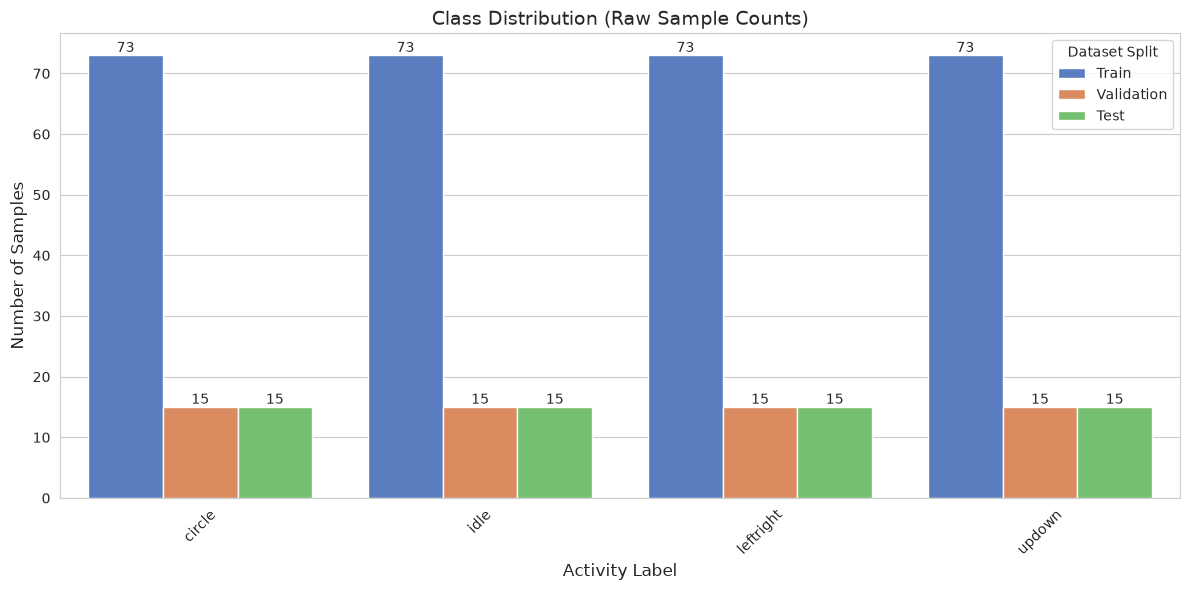


Normalization Stats:
Means: [1651.90031963 1612.85577626]
Standard deviation:  [ 992.68640053 1000.57533443]


In [21]:
# Plot Raw Counts
def plot_class_distribution(data_list: DataList) -> None:


	plot_data = []
	for split_name, indices in [("Train", data_list.catagories_train_indicies), ("Validation", data_list.catagories_val_indicies), ("Test", data_list.catagories_test_indicies)]:
		
		# Getting the amounts of windows per catgory
		counts = pd.Series(indices).value_counts().sort_index()
		for class_idx in range(data_list.num_classes):
			count = counts.get(class_idx, 0)
			plot_data.append({
				"Class": data_list.classes[class_idx],
				"Split": split_name,
				"Count": count
			})
			
	df_plot = pd.DataFrame(plot_data)

	plt.figure(figsize=(12, 6))
	sns.set_style("whitegrid")
	ax = sns.barplot(data=df_plot, x="Class", y="Count", hue="Split", palette="muted")
	for container in ax.containers:
		ax.bar_label(container, fontsize=10)
	
	plt.title("Class Distribution (Raw Sample Counts)", fontsize=14)
	plt.ylabel("Number of Samples", fontsize=12)
	plt.xlabel("Activity Label", fontsize=12)
	plt.xticks(rotation=45)
	plt.legend(title="Dataset Split")
	plt.tight_layout()
	plt.show()

print("\n--- GENERATING DISTRIBUTION PLOT ---")
plot_class_distribution(data_list)


print(f"\nNormalization Stats:")
print(f"Means: {data_list.mean}")
print(f"Standard deviation:  {data_list.standard_deviation}")


--- PLOTTING AVERAGE WAVEFORMS ---


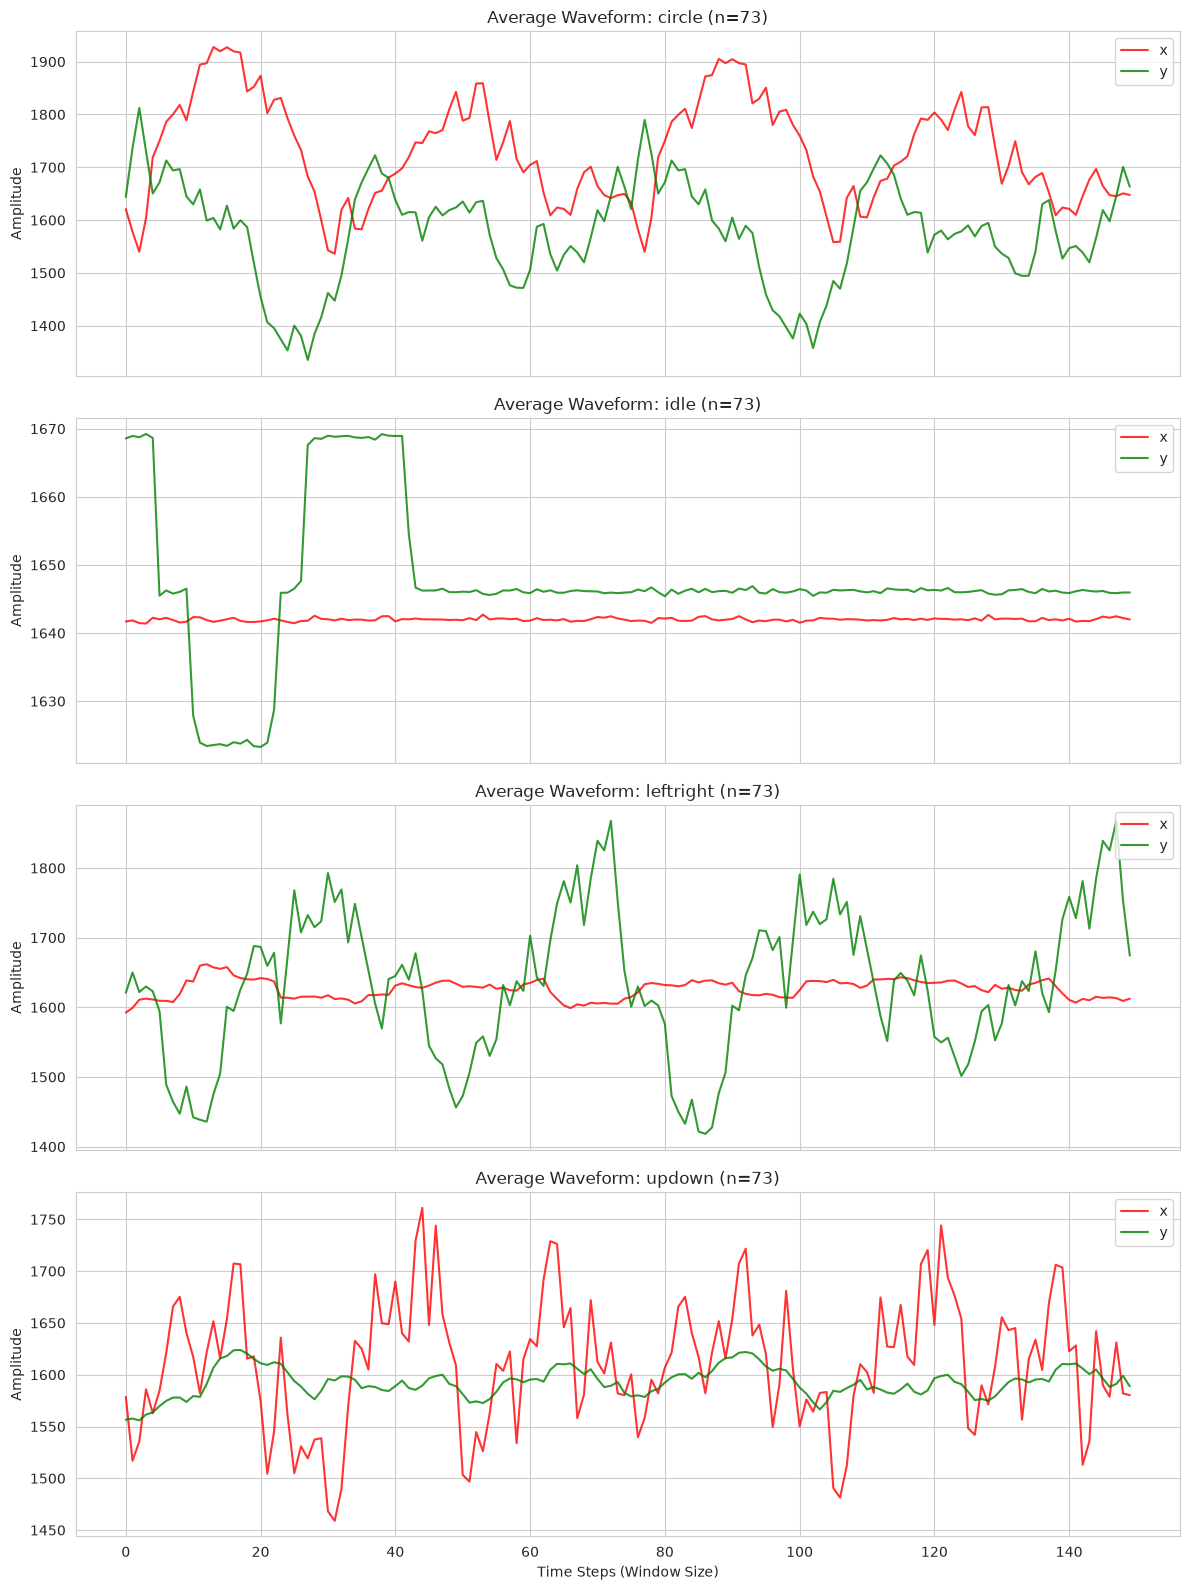

In [22]:
# ==========================================
# 4. PLOT AVERAGE WAVEFORMS PER CLASS
# ==========================================
def plot_average_waveforms(data_list: DataList) -> None:
	fig, axes = plt.subplots(data_list.num_classes, 1, figsize=(12, 4 * data_list.num_classes), sharex=True)
	
	if data_list.num_classes == 1: axes = [axes]

	time_steps = np.arange(data_list.windows_train_raw.shape[1])

	for i, class_name in enumerate(data_list.classes):
		# Filter all windows belonging to this class
		class_indices = np.where(data_list.catagories_train_indicies == i)[0]
		class_windows : window_list_type = data_list.windows_train_raw[class_indices]
		
		# Calculate the mean across all windows for this class (axis 0)
		# Result shape: (WINDOW_SIZE, 3)
		mean_waveform = np.mean(class_windows, axis=0)
		
		# Plot X, Y, Z
		ax = axes[i]
		for j, label in enumerate(DATA_CODEC.get_columns()):
			ax.plot(time_steps, mean_waveform[:, j], label=label, color=COLORS[j % len(COLORS)], alpha=0.8)

		
		ax.set_title(f"Average Waveform: {class_name} (n={len(class_indices)})")
		ax.set_ylabel("Amplitude")
		ax.legend(loc="upper right")
		ax.grid(True)

	plt.xlabel("Time Steps (Window Size)")
	plt.tight_layout()
	plt.show()

print("\n--- PLOTTING AVERAGE WAVEFORMS ---")
plot_average_waveforms(data_list)


--- TRAINING MODEL ---
Epoch 1/200


/home/finja/Documents/Diplomarbeit/EdgeAI/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4384 - loss: 1.3263 - val_accuracy: 0.7500 - val_loss: 1.2677
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7466 - loss: 1.2405 - val_accuracy: 0.7500 - val_loss: 1.1915
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7466 - loss: 1.1669 - val_accuracy: 0.7500 - val_loss: 1.1189
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7466 - loss: 1.0892 - val_accuracy: 0.7500 - val_loss: 1.0395
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8459 - loss: 1.0090 - val_accuracy: 1.0000 - val_loss: 0.9582
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9897 - loss: 0.9219 - val_accuracy: 1.0000 - val_loss: 0.8728
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9897 - loss: 0.8364 - val_accuracy: 1.0000 - val_loss: 0.7938
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9932 - loss: 0.7537 - val_accuracy: 1.0000 - val_loss:

Original model saved to: ../../MHOOP_outputs/model.h5

--- PLOTTING TRAINING CURVES ---


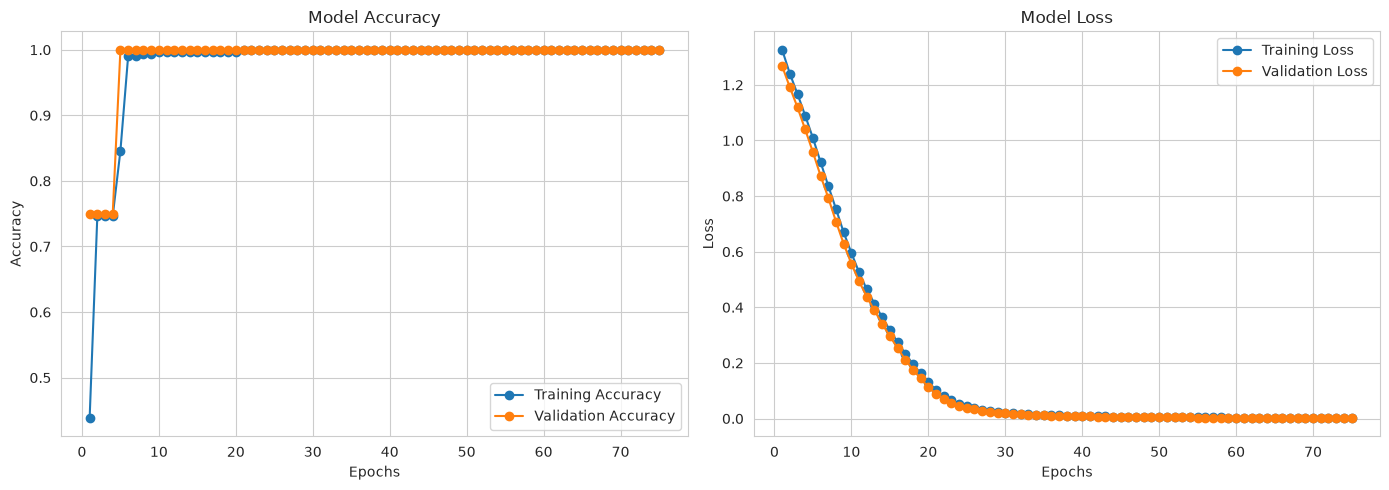


--- EVALUATION ON TEST SET ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
              precision    recall  f1-score   support

      circle       1.00      1.00      1.00        15
        idle       1.00      1.00      1.00        15
   leftright       1.00      1.00      1.00        15
      updown       1.00      1.00      1.00        15

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


--- PLOTTING CONFUSION MATRIX ---


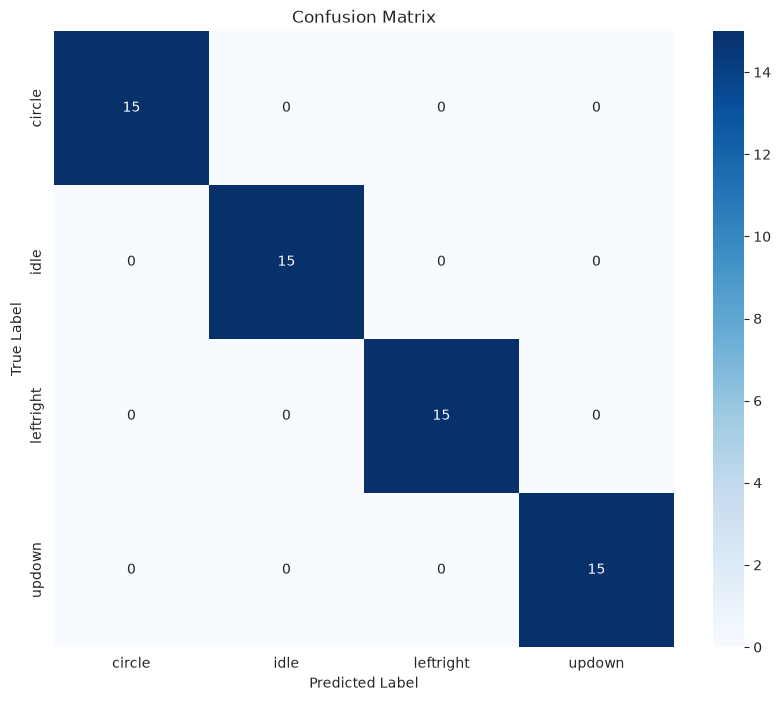

In [23]:
# ==========================================
# 5. MODEL TRAINING (1D CNN)
# ==========================================


# Defining the model using different layers
# The first layer is the input layer and the last is the output
# kernel_size specifies how many values each kernel/nodes has. If we use X, Y, Z kernel_size must be 3
model = Sequential([
    Conv1D(filters = 16, kernel_size = KERNEL_SIZE, activation = 'relu', input_shape = (WINDOW_SIZE, DATA_CODEC.get_dimensions())),
    MaxPooling1D(pool_size = 2),
    Conv1D(filters = 32, kernel_size = KERNEL_SIZE, activation = 'relu'),
    GlobalAveragePooling1D(),
    Dense(data_list.num_classes, activation = 'softmax')
])



model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Condition for stopping training
early_stopping = EarlyStopping(
    monitor='val_loss',  # Watch the validation loss
    min_delta=0.001,
    patience=10,         # Stop if it doesn't improve for 10 epochs
    restore_best_weights=True # Go back to the best model found
)

# Training the model
print("\n--- TRAINING MODEL ---")
history = model.fit(
    data_list.windows_train_normalized, data_list.catagories_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(data_list.windows_val_normalized, data_list.catagories_val),
    callbacks=[early_stopping],
    verbose=1
)

# SAVE ORIGINAL H5 MODEL
h5_path = os.path.join(OUTPUT_FOLDER, "model.h5")
model.save(h5_path)
print(f"Original model saved to: {h5_path}")

# ==========================================
# 6. PLOT TRAINING HISTORY
# ==========================================
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("\n--- PLOTTING TRAINING CURVES ---")
plot_training_history(history)

# ==========================================
# 7. EVALUATION
# ==========================================
print("\n--- EVALUATION ON TEST SET ---")
y_pred = model.predict(data_list.windows_test_normalized)
y_pred_classes = np.argmax(y_pred, axis=1)
print(y_pred_classes)
# y_true_classes = np.argmax(data_list.lables_test, axis=1)
y_true_classes = data_list.catagories_test_indicies

print(classification_report(y_true_classes, y_pred_classes, target_names=data_list.classes))

# ==========================================
# 8. PLOT CONFUSION MATRIX
# ==========================================
def plot_confusion_matrix(y_true, y_pred, classes):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

print("\n--- PLOTTING CONFUSION MATRIX ---")
plot_confusion_matrix(y_true_classes, y_pred_classes, data_list.classes)

In [24]:
"""# ==========================================
# 9. EXPORT & SIZE COMPARISON
# ==========================================
print("\n--- EXPORTING MODELS & COMPARING SIZES ---")

# Define paths
float_model_path = os.path.join(OUTPUT_FOLDER, "model_float32.tflite")
quant_model_path = os.path.join(OUTPUT_FOLDER, "model_quantized.tflite")

# Export Float32 Model (Non-Quantized)
converter_float = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float_model = converter_float.convert()

with open(float_model_path, "wb") as f:
    f.write(tflite_float_model)

# Export Int8 Model (Quantized)
def representative_data_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(X_train).batch(1).take(100):
        yield [tf.cast(input_value, tf.float32)]

converter_quant = tf.lite.TFLiteConverter.from_keras_model(model)
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT]
converter_quant.representative_dataset = representative_data_gen
converter_quant.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_quant.inference_input_type = tf.int8
converter_quant.inference_output_type = tf.int8

tflite_quant_model = converter_quant.convert()

with open(quant_model_path, "wb") as f:
    f.write(tflite_quant_model)

# Calculate and Print Sizes
h5_size = os.path.getsize(h5_path)
float_size = os.path.getsize(float_model_path)
quant_size = os.path.getsize(quant_model_path)
reduction_h5_to_float = (1 - (float_size / h5_size)) * 100
reduction_h5_to_int = (1 - (quant_size / h5_size)) * 100
reduction_float_to_int = (1 - (quant_size / float_size)) * 100

print(f"\nModel Size Comparison:")
print(f"  H5 Model:   {h5_size / 1024:.2f} KB")
print(f"  Float32 Model:   {float_size / 1024:.2f} KB")
print(f"  Quantized Model: {quant_size / 1024:.2f} KB")
print(f"  Reduction (TFlite Convert): {reduction_h5_to_float:.2f}%")
print(f"  Reduction (TFlite Convert + quantisation): {reduction_h5_to_int:.2f}%")
print(f"  Reduction (quantisation): {reduction_float_to_int:.2f}%")

# ============================================
# 10. Generate C++ Header for Validation Data
# ============================================

print("\n--- GENERATING C++ HEADER (validation_data.h) ---")

num_samples = 5
indices = np.random.choice(len(X_test), num_samples)
samples_raw = X_test_raw[indices]
true_labels = y_test[indices]
"""
#cpp_content = f"""
"""
#ifndef VALIDATION_DATA_H
#define VALIDATION_DATA_H

// Auto-generated validation data
// Class Map: {dict(zip(range(num_classes), class_names))}

const int num_validation_samples = {num_samples};

// Raw Input Data (Before Normalization)
const int16_t validation_samples[{num_samples}][{WINDOW_SIZE}][3] = {{
"""
"""
for sample in samples_raw:
    cpp_content += "    {\n"
    for row in sample:
        cpp_content += f"        {{ {int(row[0])}, {int(row[1])}, {int(row[2])} }},\n"
    cpp_content += "    },\n"

cpp_content += "};\n\n"
cpp_content += f"// Expected Classes (Indices): {np.argmax(true_labels, axis=1).tolist()}\n"
cpp_content += "#endif // VALIDATION_DATA_H\n"

header_path = os.path.join(OUTPUT_FOLDER, "validation_data.h")
with open(header_path, "w") as f:
    f.write(cpp_content)

print("Saved 'validation_data.h'")
print("Done!")"""

'\nfor sample in samples_raw:\n    cpp_content += "    {\n"\n    for row in sample:\n        cpp_content += f"        {{ {int(row[0])}, {int(row[1])}, {int(row[2])} }},\n"\n    cpp_content += "    },\n"\n\ncpp_content += "};\n\n"\ncpp_content += f"// Expected Classes (Indices): {np.argmax(true_labels, axis=1).tolist()}\n"\ncpp_content += "#endif // VALIDATION_DATA_H\n"\n\nheader_path = os.path.join(OUTPUT_FOLDER, "validation_data.h")\nwith open(header_path, "w") as f:\n    f.write(cpp_content)\n\nprint("Saved \'validation_data.h\'")\nprint("Done!")'